# Transforms

In [4]:
"""All TorchVision datasets have two parameters -transform to modify the features and target_transform to modify the labels - that accept callables containing the transformation logic. """

'All TorchVision datasets have two parameters -transform to modify the features and target_transform to modify the labels - that accept callables containing the transformation logic. '

In [7]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    ),
)

# ToImage() and ToDtype()

In [12]:
"""The torchvision.transforms.v2 API replaces the legacy ToTensor transform with a two-step pipeline. v2.ToImage converts a PIL image or NumPy ndarray into a torchvision.tv_tensors.Image tensor, and v2.ToDtype with scale=True casts it to float32 and scales the pixel intensity values to the range [0., 1.]."""

'The torchvision.transforms.v2 API replaces the legacy ToTensor transform with a two-step pipeline. v2.ToImage converts a PIL image or NumPy ndarray into a torchvision.tv_tensors.Image tensor, and v2.ToDtype with scale=True casts it to float32 and scales the pixel intensity values to the range [0., 1.].'

## Lambda Transforms

In [15]:
target_transform = v2.Lambda(
    lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
)

## Getting started with transforms v2

In [74]:
img = decode_image("Peace.jpg")

In [90]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
plt.rcParams["savefig.bbox"] = 'tight'

from torchvision.transforms import v2
from torchvision.io import decode_image

torch.manual_seed(1)

# If you're trying to run that on Colab, you can download the assets and the
# helpers from https://github.com/pytorch/vision/tree/main/gallery
from helpers import plot
img = decode_image("Peace.jpg")
print(f"{type(img) = }, {img.dtype = }, {img.shape = }")

type(img) = <class 'torch.Tensor'>, img.dtype = torch.uint8, img.shape = torch.Size([3, 1104, 736])


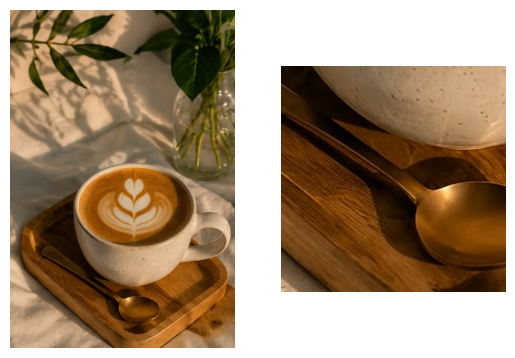

In [92]:
transform = v2.RandomCrop(size=(224, 224))
out = transform(img)

plot([img, out])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.077661].


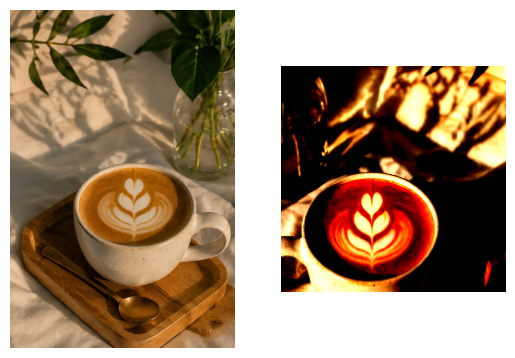

In [94]:
transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
out = transforms(img)

plot([img, out])

<class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'> <class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'>


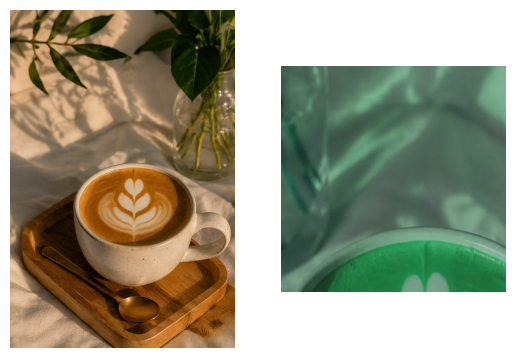

In [98]:
from torchvision import tv_tensors  # we'll describe this a bit later, bare with us

boxes = tv_tensors.BoundingBoxes(
    [
        [15, 10, 370, 510],
        [275, 340, 510, 510],
        [130, 345, 210, 425]
    ],
    format="XYXY", canvas_size=img.shape[-2:])

transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomPhotometricDistort(p=1),
    v2.RandomHorizontalFlip(p=1),
])
out_img, out_boxes = transforms(img, boxes)
print(type(boxes), type(out_boxes))

plot([img, out_img])

In [100]:
img_dp = tv_tensors.Image(torch.randint(0, 256, (3, 256, 256), dtype=torch.uint8))

print(f"{isinstance(img_dp, torch.Tensor) = }")
print(f"{img_dp.dtype = }, {img_dp.shape = }, {img_dp.sum() = }")

isinstance(img_dp, torch.Tensor) = True
img_dp.dtype = torch.uint8, img_dp.shape = torch.Size([3, 256, 256]), img_dp.sum() = tensor(25087156)


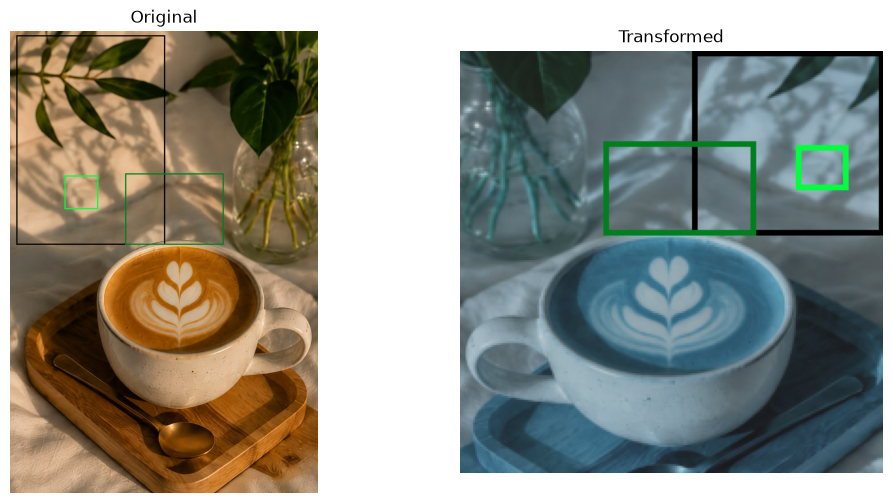

('arbitrary', {'structure': '!'})


In [104]:
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt

target = {
    "boxes": boxes,
    "labels": torch.arange(boxes.shape[0]),
    "this_is_ignored": ("arbitrary", {"structure": "!"})
}

# Apply transforms
out_img, out_target = transforms(img, target)

# Draw boxes on original image
img_with_boxes = draw_bounding_boxes(
    img,
    target["boxes"],
    width=3
)

# Draw boxes on transformed image
out_img_with_boxes = draw_bounding_boxes(
    out_img,
    out_target["boxes"],
    width=3
)

# Display side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_with_boxes.permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(out_img_with_boxes.permute(1, 2, 0))
axes[1].set_title("Transformed")
axes[1].axis("off")

plt.show()

# Verify ignored data is preserved
print(out_target["this_is_ignored"])